In [11]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import  pandas as pd 
import json 
import os
from glob import glob
import seaborn as sns 
import numpy as np 
import re
import tikzplotly
import plotly.express as px
from IPython.display import display
from PIL import Image
import matplotlib as mpl
import matplotlib.pyplot as plt 
import plotly 
import plotly.graph_objects as go
# If you want to import all functions from benchmark-utils.py, use the following:
import sys
sys.path.append('../utils')
from benchmark_utils import *

In [12]:
folders = ["../../../bucket-out/20251003_141008_modubft/","../../../bucket-out/20251003_142706_cluster_6_6/"]

folder=folders[0]


df:pd.DataFrame = merge_benchmark_results(folders)
df = assign_cluster_and_role(df)
df["cpu"] = clean_dool_data(df).Dool.apply(extract_max_cpu_usage)


In [13]:
clients = df.query("Role == 0").groupby("folder")[["Throughput"]].sum().reset_index().sort_values("folder")

fig = go.Figure() 
fig.add_trace(go.Bar(x=clients.folder,y=clients.Throughput.astype(float)))
fig.show()

In [14]:
def plot_max_cpu_by_folder(role):
    folder_cpu_max = df.query("Role == @role ").groupby("folder")[["cpu"]].max().reset_index().sort_values("folder")
    fig = go.Figure() 
    fig.add_trace(go.Bar(x=folder_cpu_max.folder,y=folder_cpu_max.cpu.astype(float)))
    fig.show()

plot_max_cpu_by_folder(2)
plot_max_cpu_by_folder(1)

In [15]:
def generate_pivot_tables_with_bytes(df):
    def generate_bytes_pivot_table(r):
        if r["Role"] == 0:
            return pd.DataFrame()
        df_bytes = pd.DataFrame(r["BytesSentTo"])
        df_bytes["ToRole"] = df_bytes["CID"].apply(lambda cid: r["IDtoRole"][cid])
        pivot = df_bytes.pivot_table(columns='Typ', values='Value', aggfunc='sum')
        pivot['index'] = r.name  # Use row index for merging
        return pivot.reset_index()

# Collect all pivot tables
    pivot_tables = [generate_bytes_pivot_table(row) for _, row in df.iterrows() if row["Role"] != 0]
    pivot_df = pd.concat(pivot_tables, ignore_index=True).fillna(0)

# Merge with original df on index
    df_with_bytes = df.merge(pivot_df, left_index=True, right_on='index', how='left')
    return df_with_bytes

df_with_bytes = generate_pivot_tables_with_bytes(df)


In [16]:
types = ["Checkpoint",	"ClientResponse"	,"ClusterCommit"	,"ClusterPrePrepare"	,"ClusterPrepare"	,"Commit"	,"PrePrepare"	,"Prepare"]
types=list(filter(lambda typ: typ in df_with_bytes,types))

average_by_folder_and_role = df_with_bytes.groupby(["folder","Role"]).mean(numeric_only=True).reset_index()
total_bytes_sent = average_by_folder_and_role[["folder","Role"]+types].groupby(["folder","Role"]).sum().sum(axis=1).reset_index().set_index(["folder","Role"])
total_bytes_sent[0].index.set_names(['folder', 'Role'], inplace=True)

normalized_bytes_per_folder = (
    average_by_folder_and_role.set_index(["folder", "Role"])[types]
    .div(total_bytes_sent[0], axis=0)
    .reset_index()
)
normalized_bytes_per_folder["Role"]=average_by_folder_and_role["Role"]
fig = go.Figure()

for typ in types:
    fig.add_trace(go.Bar(x=normalized_bytes_per_folder.Role.apply(str)+normalized_bytes_per_folder.folder.apply(str),y=normalized_bytes_per_folder[typ],name=typ))
fig.update_layout(barmode='stack')
fig.show()

In [17]:
total_bytes_sent[0]/df.groupby(["folder","Role"])[["RunTime"]].mean().RunTime*8*10**(-9)

folder                                            Role
../../../bucket-out/20251003_141008_modubft/      0       0.000000
                                                  1       0.104379
                                                  2       2.343210
../../../bucket-out/20251003_142706_cluster_6_6/  0       0.000000
                                                  1       1.023774
                                                  2       3.713000
dtype: float64

/usr/bin/chromium-browser: 12: xdg-settings: not found
Serving web UI on http://localhost:8011


../../../bucket-out/20251003_142706_cluster_6_6/


/usr/bin/chromium-browser: 12: xdg-settings: not found
[1245574:1245574:1003/145326.078695:ERROR:dbus/object_proxy.cc:573] Failed to call method: org.freedesktop.DBus.Properties.GetAll: object_path= /org/freedesktop/UPower/devices/DisplayDevice: org.freedesktop.DBus.Error.ServiceUnknown: The name org.freedesktop.UPower was not provided by any .service files
192201 bytes written to file /mnt/c/Users/Andre/OneDrive/Cloud-Native Byzantine Consensus/code/CloudModuBFT/src/evaluation/notebooks/imgs/1759496004.9930136.png


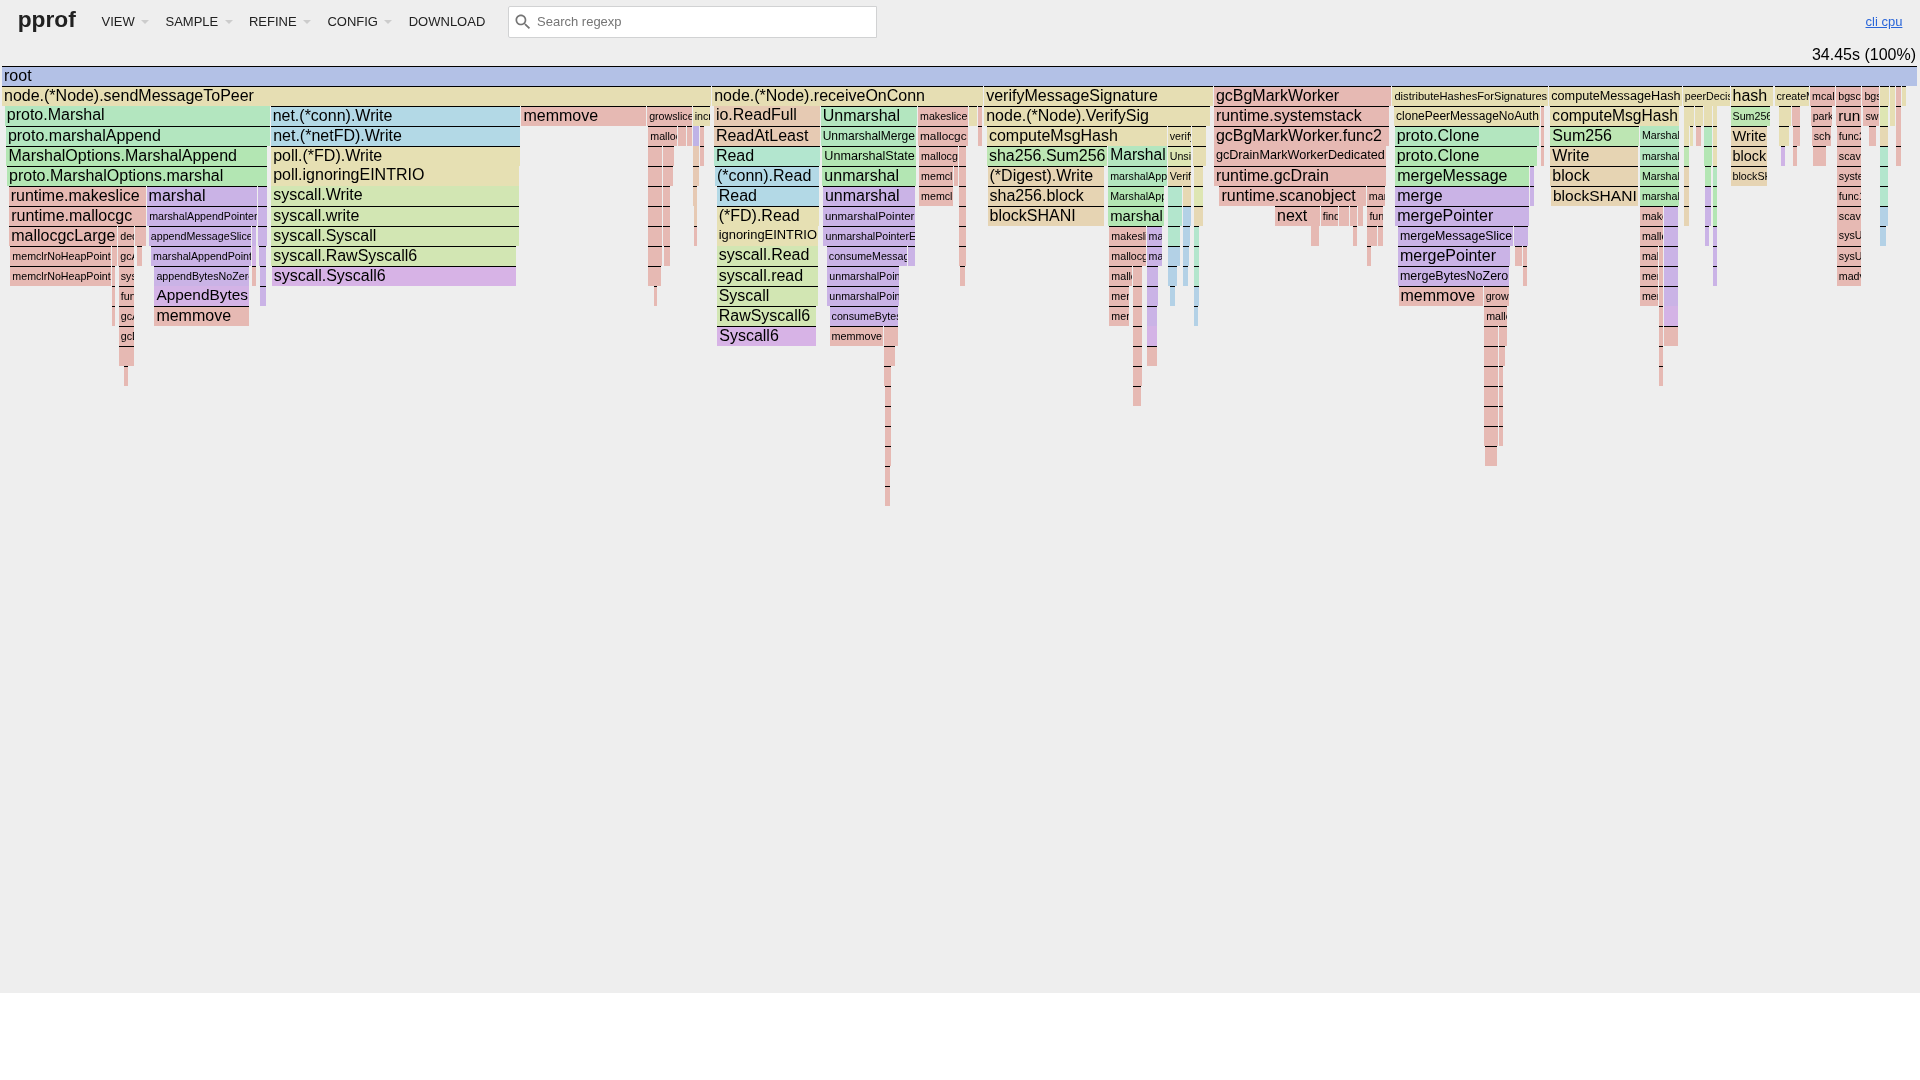

go tool pprof: signal: terminated
Serving web UI on http://localhost:8012


../../../bucket-out/20251003_141008_modubft/


/usr/bin/chromium-browser: 12: xdg-settings: not found
[1246028:1246028:1003/145333.594078:ERROR:dbus/object_proxy.cc:573] Failed to call method: org.freedesktop.DBus.Properties.GetAll: object_path= /org/freedesktop/UPower/devices/DisplayDevice: org.freedesktop.DBus.Error.ServiceUnknown: The name org.freedesktop.UPower was not provided by any .service files
184087 bytes written to file /mnt/c/Users/Andre/OneDrive/Cloud-Native Byzantine Consensus/code/CloudModuBFT/src/evaluation/notebooks/imgs/1759496012.806333.png


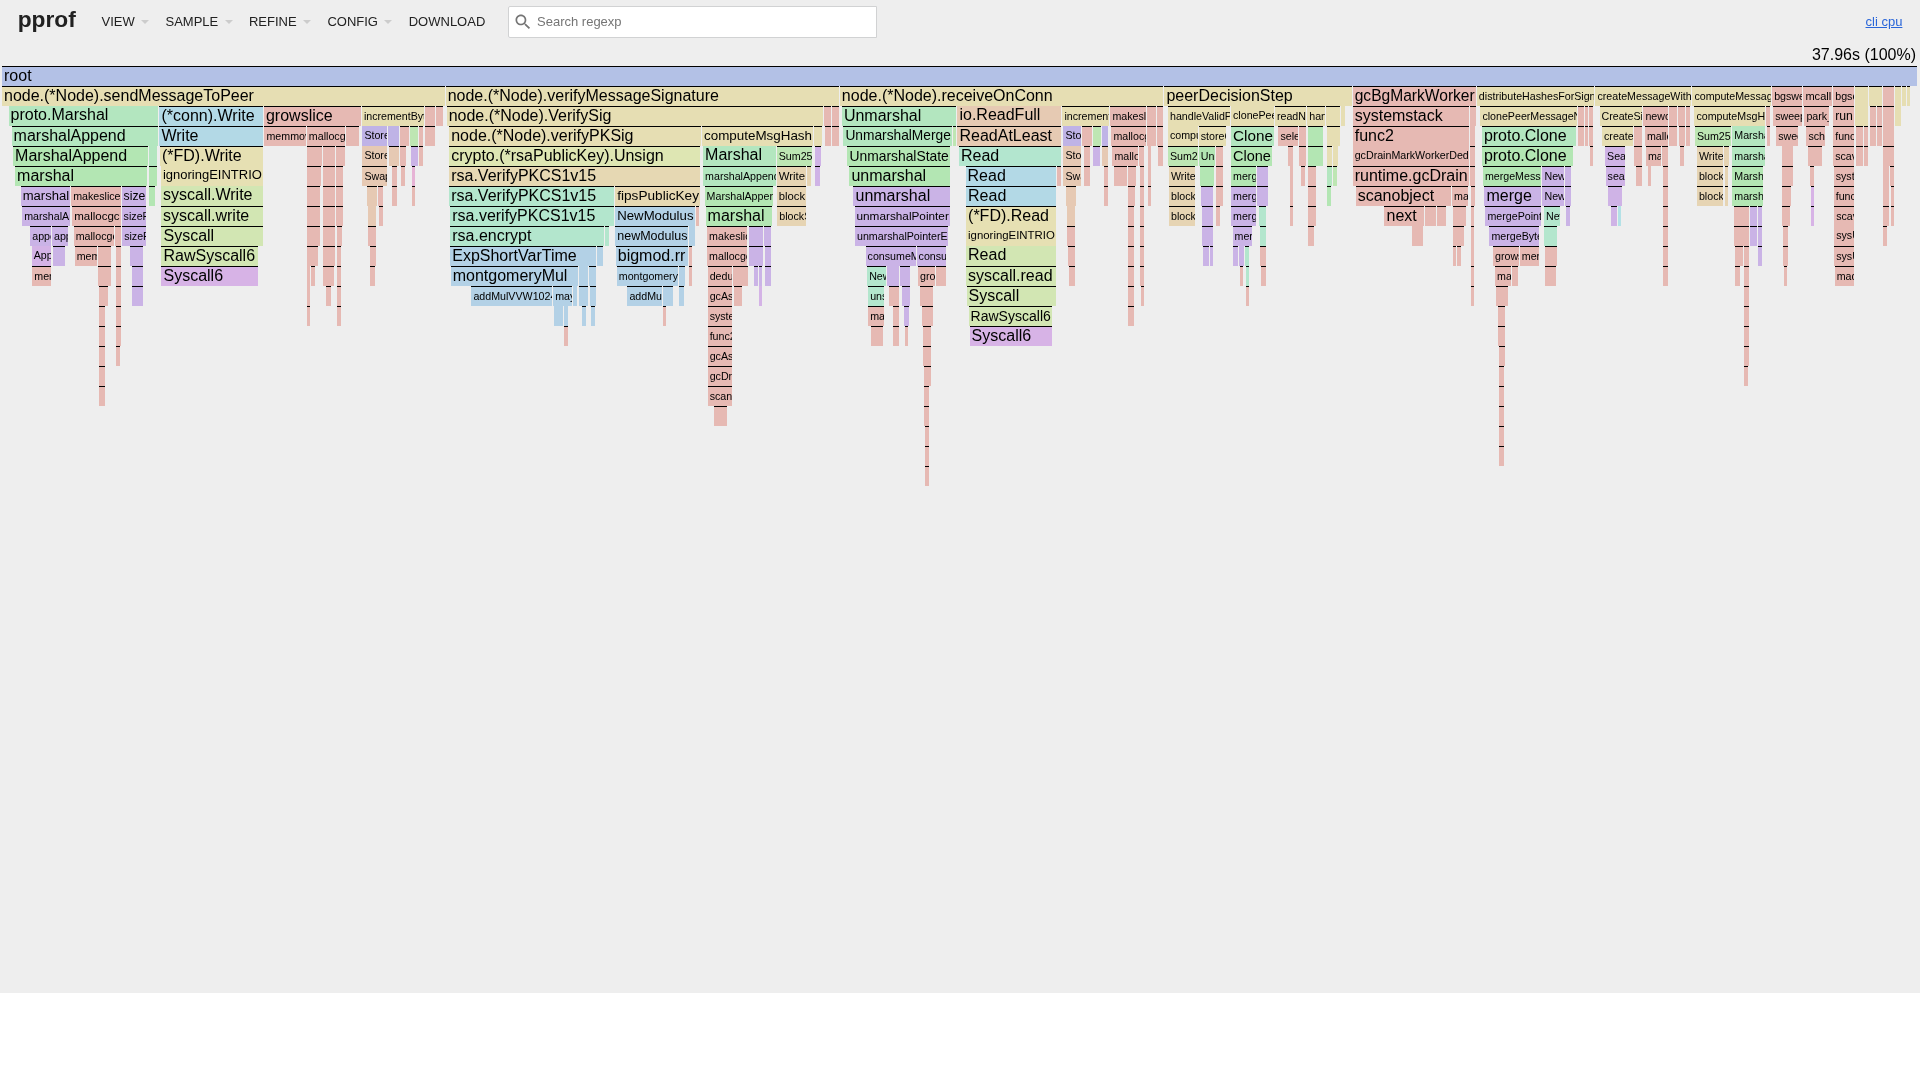

go tool pprof: signal: terminated


In [ ]:
import subprocess
import requests
import time
from IPython.display import IFrame
import signal
from IPython.display import Image


from html2image import Html2Image
hti = Html2Image(browser_executable='/usr/bin/chromium-browser',output_path="./imgs")
port = 8010
for folder in reversed(folders):
    port +=1 
    try: 
        p = subprocess.Popen(["go","tool","pprof","-no_browser","-http",f"localhost:{port}",os.path.join(folder,"cli"), os.path.join(folder,"cpu.prof")] ,start_new_session=True)
        time.sleep(4)
   
    
        print(folder)
        flamegraph_url = f"http://localhost:{port}/ui/flamegraph"
        timestamp = time.time()
        
        screenshot_filename = f"{timestamp}.png"
        hti.screenshot(url=flamegraph_url,save_as=screenshot_filename)

        display(Image("./imgs/"+screenshot_filename))

       
        p.wait(timeout=2)
    except subprocess.TimeoutExpired: 
        os.killpg(os.getpgid(p.pid), signal.SIGTERM)
    except Exception as e :
        os.killpg(os.getpgid(p.pid), signal.SIGTERM)
        raise e 
        

